In [1]:
%matplotlib inline

In [3]:
#Import Libraries here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as scs
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from sktime.transformations.series.outlier_detection import HampelFilter
import os
import sys

In [5]:
current_dir = os.path.abspath('')
project_root = os.path.abspath(os.path.join(current_dir, '../'))

if project_root not in sys.path:
    sys.path.append(project_root)

os.chdir(project_root)

print(f"Working directory set to: {os.getcwd()}")

Working directory set to: D:\users\kamen.dimitrov\desktop\softuni\AI_and_ML_upskill_program\Data Science\08_final_project


In [6]:
#Import project modules here

import importlib
from src.data_pipeline_utils import data_fetching_handling as data_pipe
import src.plotting_utils.plotting_utils as plot_utils
importlib.reload(plot_utils)
importlib.reload(data_pipe)

<module 'src.data_pipeline_utils.data_fetching_handling' from 'D:\\users\\kamen.dimitrov\\desktop\\softuni\\AI_and_ML_upskill_program\\Data Science\\08_final_project\\src\\data_pipeline_utils\\data_fetching_handling.py'>

# Project Overview

This project investigates whether past stock returns and company-related news contain statistically useful structure that can be detected through two complementary approaches: price-based time-series signals and text-based information from company news. 

# Thesis
#TODO

The first stage builds a clean financial dataset and explores the statistical properties of returns, including volatility, outliers, distribution shape, and persistence. Later stages test whether these features can be converted into predictive signals for subsequent returns.

# 1. Prepare data using the pipeline

In [6]:
tickers = ['AAPL', 'NVDA', 'MSFT', 'JNJ', 'BAC', 'VZ', 'WMT', 'UPS', 'PFE', 'JPM']
all_df_shapes = {}

for ticker in tickers:
    data = data_pipe.save_10_year_single_stock_data_to_csv(ticker)
    return_data = data_pipe.create_returns_and_save(data, ticker)
    all_df_shapes[ticker] = return_data.shape

all_same = set(all_df_shapes.values())
print(f"{len(all_same)} - a result of 1 is a green light to go as all datasets are complete, if not go back and choose different stocks")

1 - a result of 1 is a green light to go as all datasets are complete, if not go back and choose different stocks


In [7]:
MSFT_data = data_pipe.fetch_raw_data('MSFT')
return_data_PFE = data_pipe.fetch_returns_data('PFE')

return_data_PFE

,Close,High,Low,Open,Volume,daily_return,log_return,daily_return_pct,log_return_pct
Date,,,,,,,,,
2016-03-29,18.401909,18.487643,18.193702,18.261063,36464395,0.009066,0.009025,0.906611,0.902525
2016-03-30,18.414164,18.499897,18.377422,18.463154,33824546,0.000666,0.000666,0.066595,0.066573
2016-03-31,18.150843,18.475402,18.071233,18.408040,59861719,-0.014300,-0.014403,-1.429991,-1.440314
2016-04-01,18.395788,18.475397,18.009991,18.028361,50975340,0.013495,0.013405,1.349499,1.340475
2016-04-04,18.812212,18.830584,18.408043,18.426415,54762573,0.022637,0.022384,2.263691,2.238450
...,...,...,...,...,...,...,...,...,...
2026-03-19,27.410000,27.730000,27.250000,27.290001,47939600,0.003294,0.003289,0.329430,0.328888
2026-03-20,26.969999,27.549999,26.799999,27.410000,66805700,-0.016053,-0.016183,-1.605256,-1.618279
2026-03-23,26.770000,27.190001,26.629999,27.030001,42945200,-0.007416,-0.007443,-0.741560,-0.744324


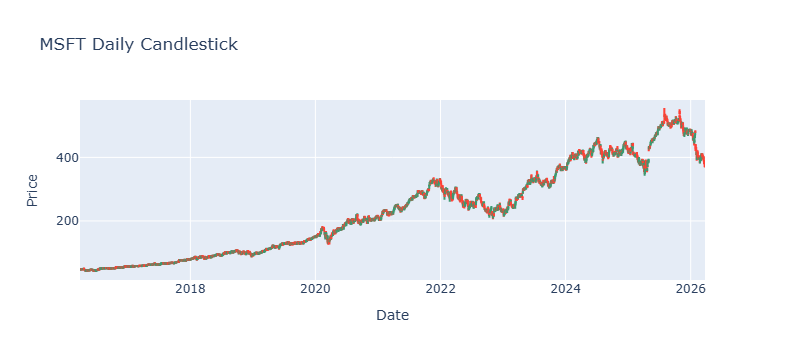

In [8]:
fig = plot_utils.create_candlestick_graph('MSFT')
fig.show()

# 2. Here we deviate from the previous project. Let's do some time series data exploration
Let's work with the returns dataframe created above

-  the rolling method in Pandas with parameters:
-  window = 21, we choose this for 21 trading days on average in a month
-  min_periods = 1, for the first 20 rows it gradually expands until it reaches 21
-  dropna(), because on the earliest day (first row), column 'std' remains NaN

In [22]:
stats = return_data_PFE['log_return'].rolling(window=21, min_periods=1).agg(['mean', 'std'])
return_data_PFE = pd.concat([return_data_PFE, stats], axis=1)

return_data_PFE

,Close,High,Low,Open,Volume,daily_return,log_return,daily_return_pct,log_return_pct,mean,std
Date,,,,,,,,,,,
2016-03-29,18.401909,18.487643,18.193702,18.261063,36464395,0.009066,0.009025,0.906611,0.902525,0.009025,NaN
2016-03-30,18.414164,18.499897,18.377422,18.463154,33824546,0.000666,0.000666,0.066595,0.066573,0.004845,0.005911
2016-03-31,18.150843,18.475402,18.071233,18.408040,59861719,-0.014300,-0.014403,-1.429991,-1.440314,-0.001571,0.011873
2016-04-01,18.395788,18.475397,18.009991,18.028361,50975340,0.013495,0.013405,1.349499,1.340475,0.002173,0.012249
2016-04-04,18.812212,18.830584,18.408043,18.426415,54762573,0.022637,0.022384,2.263691,2.238450,0.006215,0.013937
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-19,27.410000,27.730000,27.250000,27.290001,47939600,0.003294,0.003289,0.329430,0.328888,0.000070,0.013828
2026-03-20,26.969999,27.549999,26.799999,27.410000,66805700,-0.016053,-0.016183,-1.605256,-1.618279,0.000195,0.013659
2026-03-23,26.770000,27.190001,26.629999,27.030001,42945200,-0.007416,-0.007443,-0.741560,-0.744324,0.000214,0.013648


In [23]:
#TODO Create a method

N_SIGMAS = 3

return_data_PFE["upper"] = return_data_PFE["mean"] + N_SIGMAS * return_data_PFE["std"]
return_data_PFE["lower"] = return_data_PFE["mean"] - N_SIGMAS * return_data_PFE["std"]

return_data_PFE["outlier"] = (
    (return_data_PFE["log_return"] > return_data_PFE["upper"]) | 
    (return_data_PFE["log_return"] < return_data_PFE["lower"])
)

return_data_PFE = return_data_PFE.dropna()
return_data_PFE

,Close,High,Low,Open,Volume,daily_return,log_return,daily_return_pct,log_return_pct,mean,std,upper,lower,outlier
Date,,,,,,,,,,,,,,
2016-03-30,18.414164,18.499897,18.377422,18.463154,33824546,0.000666,0.000666,0.066595,0.066573,0.004845,0.005911,0.022579,-0.012888,False
2016-03-31,18.150843,18.475402,18.071233,18.408040,59861719,-0.014300,-0.014403,-1.429991,-1.440314,-0.001571,0.011873,0.034049,-0.037190,False
2016-04-01,18.395788,18.475397,18.009991,18.028361,50975340,0.013495,0.013405,1.349499,1.340475,0.002173,0.012249,0.038921,-0.034575,False
2016-04-04,18.812212,18.830584,18.408043,18.426415,54762573,0.022637,0.022384,2.263691,2.238450,0.006215,0.013937,0.048026,-0.035595,False
2016-04-05,19.204128,19.442956,18.726475,19.112272,299829377,0.020833,0.020619,2.083308,2.061904,0.008616,0.013783,0.049965,-0.032732,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-19,27.410000,27.730000,27.250000,27.290001,47939600,0.003294,0.003289,0.329430,0.328888,0.000070,0.013828,0.041552,-0.041413,False
2026-03-20,26.969999,27.549999,26.799999,27.410000,66805700,-0.016053,-0.016183,-1.605256,-1.618279,0.000195,0.013659,0.041172,-0.040783,False
2026-03-23,26.770000,27.190001,26.629999,27.030001,42945200,-0.007416,-0.007443,-0.741560,-0.744324,0.000214,0.013648,0.041156,-0.040729,False


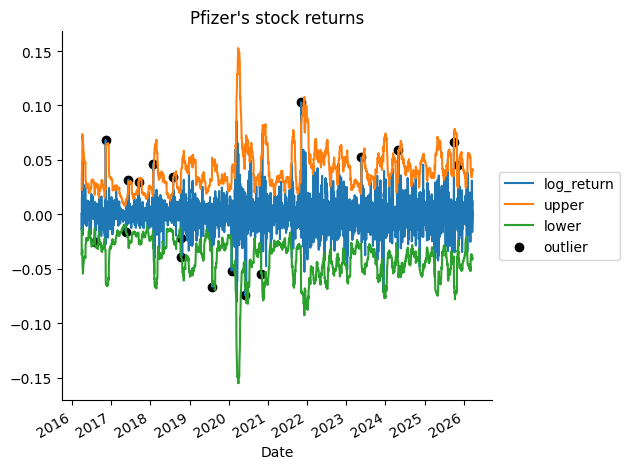

In [31]:
#TODO Create a plot util method

fig, ax = plt.subplots()

return_data_PFE[["log_return", "upper", "lower"]].plot(ax=ax)
ax.scatter(return_data_PFE.loc[return_data_PFE["outlier"]].index, 
           return_data_PFE.loc[return_data_PFE["outlier"], "log_return"], 
           color="black", label="outlier")
ax.set_title("Pfizer's stock returns")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

sns.despine()
plt.tight_layout()

C:\Users\kamen.dimitrov\AppData\Local\Temp\ipykernel_34556\2199510419.py:6: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return_data_PFE[["log_return"]].plot(ax=ax)


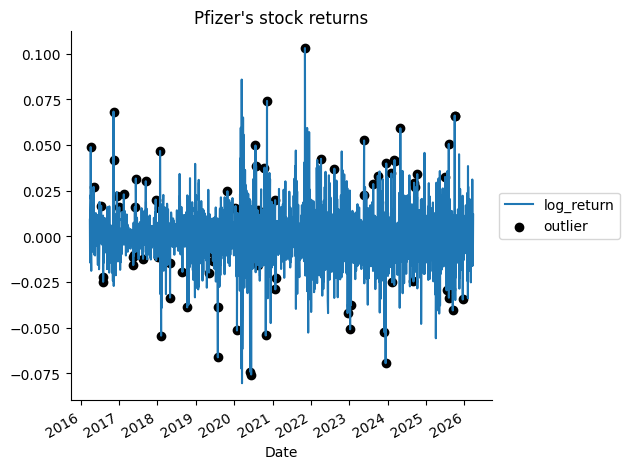

In [11]:
hampel_detector = HampelFilter(window_length=21, return_bool=True)
return_data_PFE["outlier_rtn"] = hampel_detector.fit_transform(return_data_PFE["log_return"])

fig, ax = plt.subplots()

return_data_PFE[["log_return"]].plot(ax=ax)
ax.scatter(return_data_PFE.loc[return_data_PFE["outlier_rtn"]].index, 
           return_data_PFE.loc[return_data_PFE["outlier_rtn"], "log_return"], 
           color="black", label="outlier")
ax.set_title("Pfizer's stock returns")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

sns.despine()
plt.tight_layout()

The Hurst Exponent ($H$) is a statistical measure used to classify time series data based on its "memory." In the context of your Python for Finance Cookbook, it is the primary tool for determining if a stock's price is trending, mean-reverting, or just a random walk.Mathematically, it relates to the autocorrelations of the time series and the rate at which the variance of the series increases over time.1. The Three Regimes of $H$The value of $H$ always falls between 0 and 1. Where it lands tells you the "nature" of the asset:Value of HRegimeMarket Behavior$H < 0.5$Mean-Reverting"Anti-persistent." If the price goes up, it is likely to go back down soon. Great for "Pairs Trading."$H = 0.5$Random WalkGeometric Brownian Motion. Past movement has zero influence on future movement (Efficient Market Hypothesis).$H > 0.5$Trending"Persistent." If the price is moving up, it is likely to keep moving up. Ideal for "Momentum Trading."

In [42]:
#TODO Export method in time series analysis
def get_hurst_exponent(ts, lag):
    """Returns the Hurst Exponent of a time series"""
    lags = range(2, lag)
    # Calculate the variance of the differenced series
    tau = [np.sqrt(np.std(np.subtract(ts[lag:], ts[:-lag]))) for lag in lags]
    # Use a linear fit to estimate the Hurst Exponent
    poly = np.polyfit(np.log(lags), np.log(tau), 1)
    return poly[0] * 2.0

In [43]:
for lag in [20, 100, 250, 500, 1000]:
    hurst_exp = get_hurst_exponent(return_data_PFE["Close"].values, lag)
    print(f"Hurst exponent with {lag} lags: {hurst_exp:.4f}")


Hurst exponent with 20 lags: 0.5119
Hurst exponent with 100 lags: 0.4180
Hurst exponent with 250 lags: 0.4620
Hurst exponent with 500 lags: 0.5191
Hurst exponent with 1000 lags: 0.4604


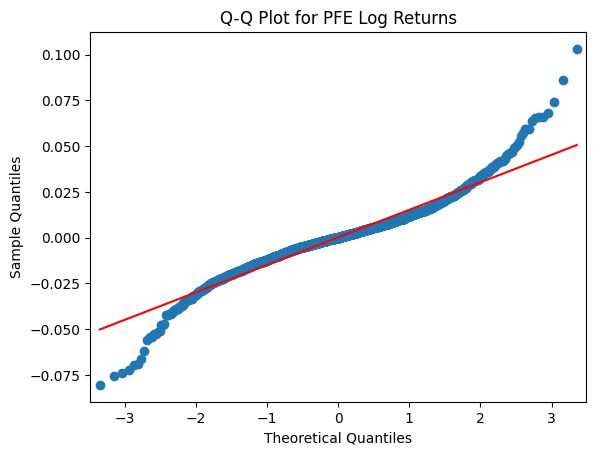

In [48]:
#TODO method in plot utils and explain further
fig = sm.qqplot(return_data_PFE['log_return'].dropna(), line='s')
plt.title("Q-Q Plot for PFE Log Returns")
plt.show()

Mean log return in observation period: 0.00015672749033900408,
Variance of log returns in observation period: 0.00022555898427227322,
Standard deviation of log returns in observation period: 0.015018621250709841


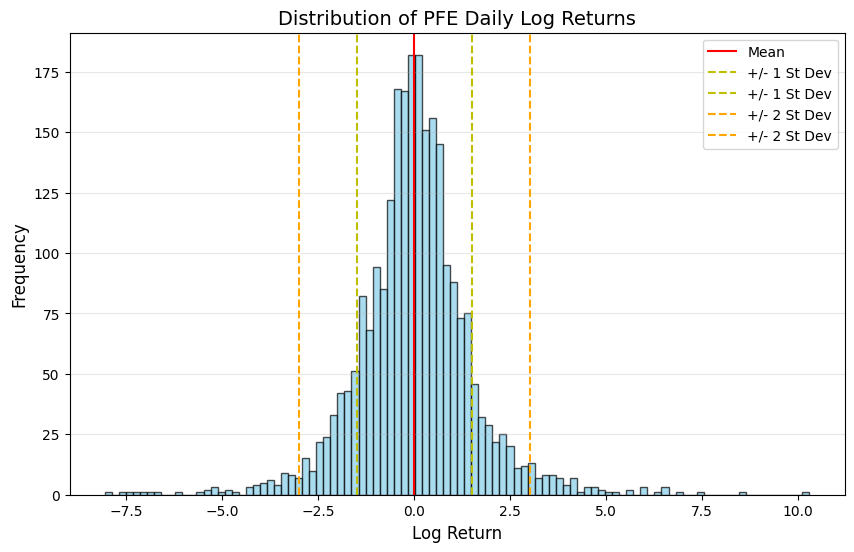

In [55]:
mean = return_data_PFE["log_return"].mean()
variance = return_data_PFE["log_return"].var()
st_dev = return_data_PFE["log_return"].std()

print(f"Mean log return in observation period: {mean},\n"
      f"Variance of log returns in observation period: {variance},\n"
      f"Standard deviation of log returns in observation period: {st_dev}")

ticker = 'PFE'
fig = plot_utils.create_histogram_distribution_daily_log_returns(return_data_PFE, ticker, mean, st_dev)
plt.show()

In [56]:
jb_test = scs.jarque_bera(return_data_PFE["log_return"].values)

print("---------- Descriptive Statistics ----------")
print("Range of dates:", min(return_data_PFE.index.date), "-", max(return_data_PFE.index.date))
print("Number of observations:", return_data_PFE.shape[0])
print(f"Mean: {return_data_PFE.log_return.mean():.4f}")
print(f"Median: {return_data_PFE.log_return.median():.4f}")
print(f"Min: {return_data_PFE.log_return.min():.4f}")
print(f"Max: {return_data_PFE.log_return.max():.4f}")
print(f"Standard Deviation: {return_data_PFE.log_return.std():.4f}")
print(f"Skewness: {return_data_PFE.log_return.skew():.4f}")
print(f"Kurtosis: {return_data_PFE.log_return.kurtosis():.4f}") 
print(f"Jarque-Bera statistic: {jb_test[0]:.2f} with p-value: {jb_test[1]:.2f}")

---------- Descriptive Statistics ----------
Range of dates: 2016-03-30 - 2026-03-25
Number of observations: 2512
Mean: 0.0002
Median: 0.0000
Min: -0.0805
Max: 0.1031
Standard Deviation: 0.0150
Skewness: 0.1566
Kurtosis: 4.5030
Jarque-Bera statistic: 2121.87 with p-value: 0.00


#TODO Conclusions

In [ ]:
#TODO Autocorrelation

In [ ]:
#TODO volatility clustering